In [47]:
import numpy as np
from utils.data_utils import TitanicDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [48]:
x_train, x_test, y_train, y_test = TitanicDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 10), (179, 10), (712,), (179,))

In [49]:
x_train.head()

,Pclass,Age,SibSp,Parch,Fare,UncommonTitle,YoungTitle,Sex_male,Embarked_Q,Embarked_S
709,0.824654,-0.091831,0.445182,0.705697,-0.339157,-0.174207,1.737341,0.741906,-0.308627,-1.593335
439,-0.376069,0.132682,-0.481630,-0.493483,-0.429806,-0.174207,-0.574784,0.741906,-0.308627,0.626733
840,0.824654,-0.690532,-0.481630,-0.493483,-0.478991,-0.174207,-0.574784,0.741906,-0.308627,0.626733
720,-0.376069,-1.738261,-0.481630,0.705697,-0.000034,-0.174207,1.737341,-1.345987,-0.308627,0.626733
39,0.824654,-1.139559,0.445182,-0.493483,-0.415639,-0.174207,1.737341,-1.345987,-0.308627,-1.593335


In [50]:
y_train.head()

709    1
439    0
840    0
720    1
39     1
Name: Survived, dtype: int64

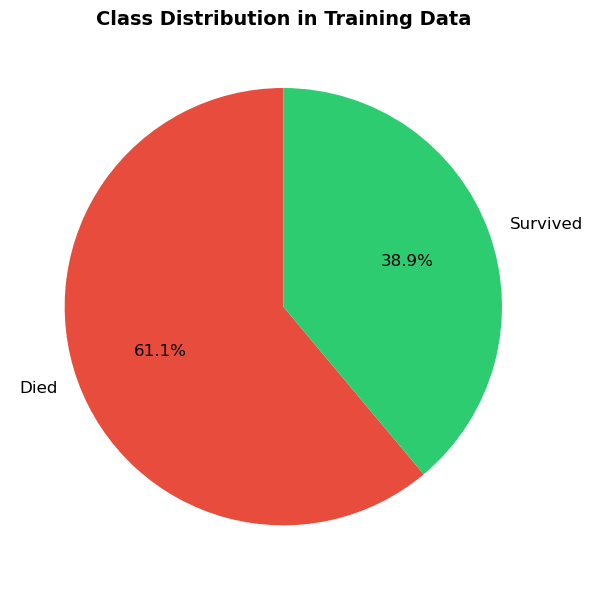

Died: 435 (61.1%)
Survived: 277 (38.9%)


In [51]:
TitanicDataHelper.plot_outcome_distribution(x_train, y_train)

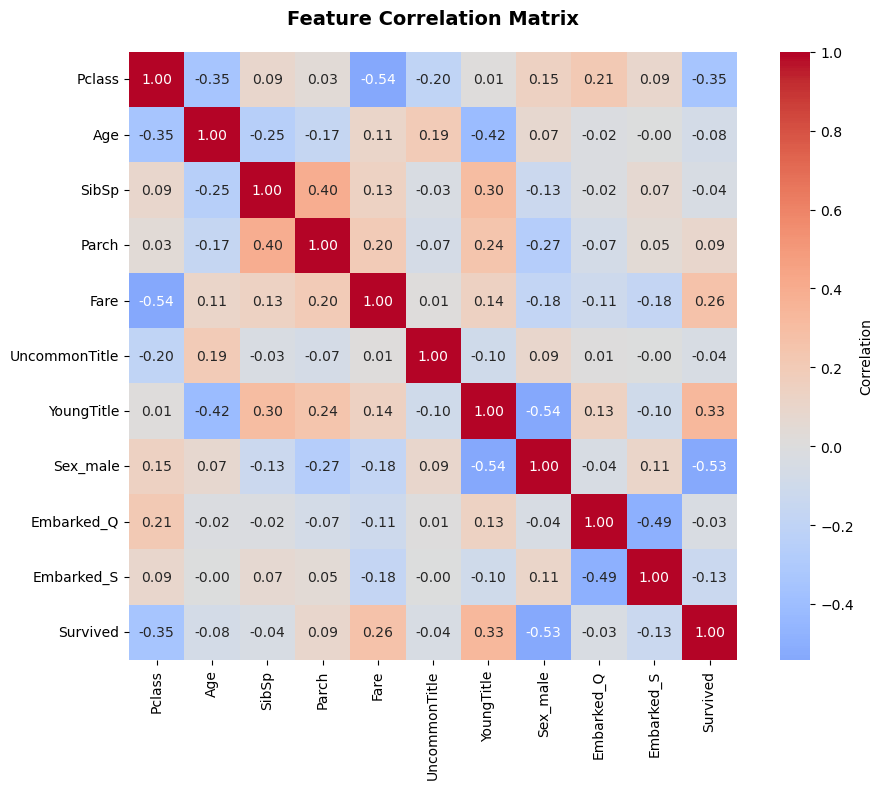

In [52]:
TitanicDataHelper.plot_correlation(x_train, y_train)

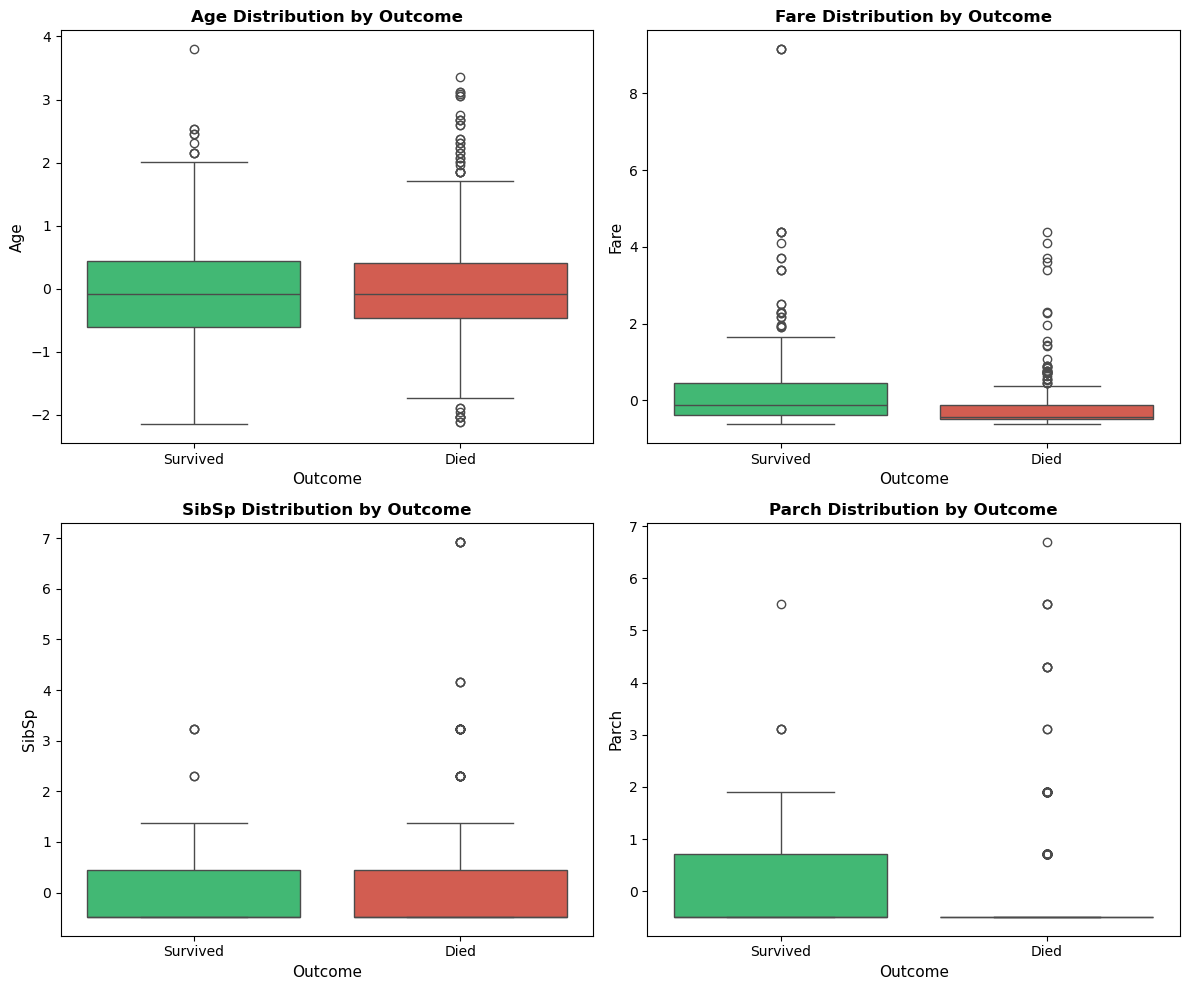

In [53]:
TitanicDataHelper.plot_boxplots(x_train, y_train)

## Model Training

In [54]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [55]:
y_train = np.where(y_train == 0, -1, 1)
y_test  = np.where(y_test == 0, -1, 1)

In [56]:
alphas = np.zeros((x_train.shape[0],))
bias = 0.0

In [57]:
def compute_similarity(x1, x2, gamma=0.05):
    dist_sq = np.sum((x1 - x2)**2)
    return np.exp(-gamma * dist_sq)

In [58]:
train_size = len(x_train)

similarities = np.zeros(shape=(train_size, train_size))

for i in range(train_size):
    for j in range(train_size):
        similarity = compute_similarity(x_train[i], x_train[j])
        similarities[i][j] = similarity

In [59]:
def decide(j):
    return np.sum(alphas * y_train * similarities[:, j]) + bias

In [60]:
errors = (alphas * y_train) @ similarities + bias - y_train

In [61]:
def update_parameters(i, j, C):
    global alphas, bias, errors
    
    kernel_dist = similarities[i][i] + similarities[j][j] - 2*similarities[i][j]
    
    if kernel_dist <= 0:
        return False
    
    if abs(errors[i] - errors[j]) < 1e-12:
        return False
    
    adjustment = y_train[j] * (errors[i] - errors[j]) / kernel_dist

    if y_train[i] != y_train[j]:
        lower_bound = max(0, alphas[j] - alphas[i])
        upper_bound = min(C, C + alphas[j] - alphas[i])
    else:
        lower_bound = max(0, alphas[i] + alphas[j] - C)
        upper_bound = min(C, alphas[i] + alphas[j])
        
    if lower_bound == upper_bound:
        return False

    new_j_alpha = alphas[j] + adjustment
    new_j_alpha = np.clip(new_j_alpha, lower_bound, upper_bound)
    
    if abs(new_j_alpha - alphas[j]) < 1e-12:
        return False

    new_i_alpha = alphas[i] + y_train[i] * y_train[j] * (alphas[j] - new_j_alpha)
    
    a1 = y_train[i] * (new_i_alpha - alphas[i]) * similarities[i][i]
    a2 = y_train[j] * (new_j_alpha - alphas[j]) * similarities[i][j]
    
    bias_1 = bias - errors[i] - a1 - a2
     
    a3 = y_train[i] * (new_i_alpha - alphas[i]) * similarities[i][j]
    a4 = y_train[j] * (new_j_alpha - alphas[j]) * similarities[j][j]
    
    bias_2 = bias - errors[j] - a3 - a4
    
    if 0 < new_i_alpha < C:
        new_bias = bias_1
    elif 0 < new_j_alpha < C:
        new_bias = bias_2
    else:
        new_bias = (bias_1 + bias_2) / 2
    
    alphas[j] = new_j_alpha
    
    alphas[i] = new_i_alpha
    bias = new_bias
    
    errors = (alphas * y_train) @ similarities + bias - y_train
    
    return True

In [62]:
def violates_kkt(i, C, tol=1e-3):
    r = y_train[i] * errors[i]
    return (r < -tol and alphas[i] < C) or (r > tol and alphas[i] > 0)

In [63]:
C = 1
support_threshold = 1e-5
epochs = 10_000

for epoch in range(epochs):
    for i in range(train_size):
        if not violates_kkt(i, C):
            continue
        
        diffs = np.abs(errors - errors[i])
        diffs[i] = -1
        
        j = np.argmax(diffs)
        success = update_parameters(i, j, C)
        
        if not success:
            j = np.random.choice([x for x in range(train_size) if x != i])
            update_parameters(i, j, C)
    
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{epochs} completed.")
        
support_indices = np.where(alphas > support_threshold)[0]

support_vectors = x_train[support_indices]
support_alphas = alphas[support_indices]
support_labels = y_train[support_indices]

print(f"Number of support vectors: {len(support_vectors)}")


Epoch 1000/10000 completed.
Epoch 2000/10000 completed.
Epoch 3000/10000 completed.
Epoch 4000/10000 completed.
Epoch 5000/10000 completed.
Epoch 6000/10000 completed.
Epoch 7000/10000 completed.
Epoch 8000/10000 completed.
Epoch 9000/10000 completed.
Epoch 10000/10000 completed.
Number of support vectors: 362


In [64]:
def predict(x):
    result = sum(support_alphas[i] * support_labels[i] * compute_similarity(support_vectors[i], x) for i in range(len(support_vectors))) + bias
    return 1 if result >= 0 else 0

## Model Evaluation

In [65]:
predictions = []

for x in x_test:
    prediction = predict(x)
    predictions.append(prediction)

predictions = np.array(predictions)

In [66]:
y_train_binary = np.where(y_train == -1, 0, 1)
y_test_binary = np.where(y_test == -1, 0, 1)

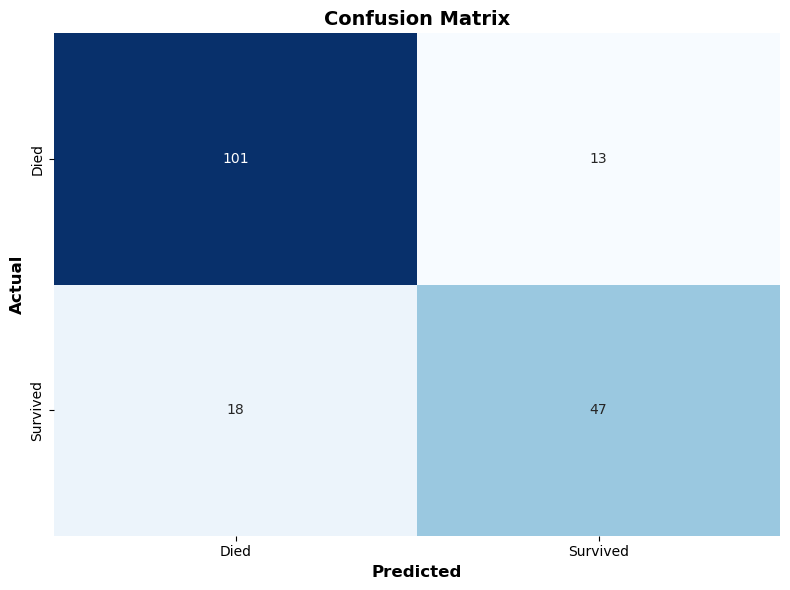

True Negatives: 101
False Positives: 13
False Negatives: 18
True Positives: 47

Sensitivity (Recall): 0.7231
Specificity: 0.8860
Precision: 0.7833
Accuracy: 0.8268
F1 Score: 0.7520


In [67]:
EvaluationHelper.plot_confusion_matrix(y_test_binary, predictions, class_names=["Died", "Survived"])

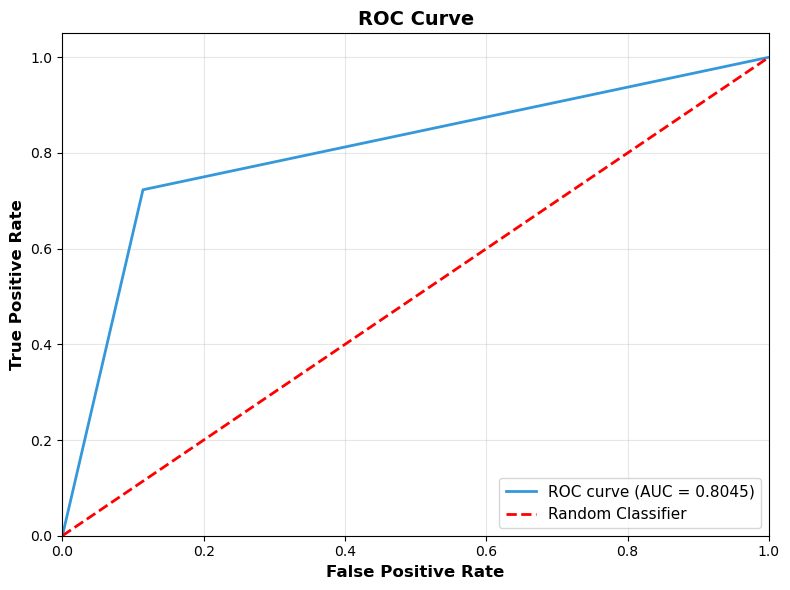

Area Under the Curve (AUC): 0.8045


In [68]:
EvaluationHelper.plot_roc_curve(y_test_binary, predictions)

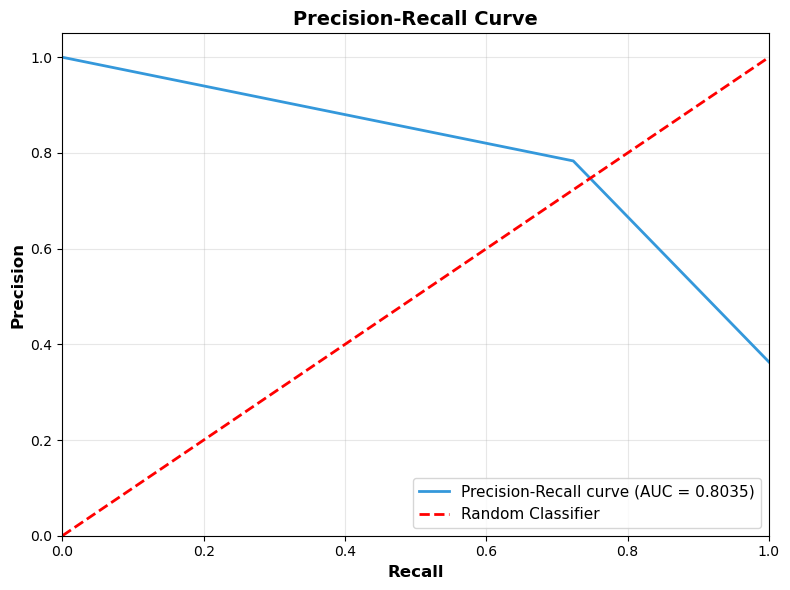

Area Under the Curve (AUC): 0.8035


In [69]:
EvaluationHelper.plot_precision_recall_curve(y_test_binary, predictions)